# Dataset Analysis

### Objective
Identify the profile of the typical customer for each treadmill product offered by CardioGood Fitness. 

### Data Dictionary
Product - The model number of the treadmill

Age - Age of the customer in no of years

Gender - Gender of the customer

Education - Education of the customer in no. of years

Marital Status - Marital status of the customer

Usage - Avg. # times the customer wants to use the treadmill every week

Fitness - Self rated fitness score of the customer (5 - very fit, 1 - very unfit)

Income - Income of the customer

Miles- Miles that a customer expects to run

### Import Packages 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True) # adds a nice background to the charts
%matplotlib inline 
# automatically displays the graph

C:\Users\codyd\AppData\Local\Temp\ipykernel_17756\212550198.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Load .csv file

In [2]:
Cardio = pd.read_csv('CardioGoodFitness.csv')

## Data Overview

In [3]:
Cardio.sample(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
99,TM498,25,Male,16,Partnered,2,2,52302,42
19,TM195,23,Female,15,Partnered,2,2,34110,38
6,TM195,21,Female,14,Partnered,3,3,35247,75
56,TM195,31,Female,14,Single,2,2,45480,47
67,TM195,37,Female,16,Partnered,3,3,37521,85
118,TM498,32,Male,16,Single,4,3,60261,127
104,TM498,25,Male,14,Partnered,3,4,43206,106
160,TM798,27,Male,18,Single,4,3,88396,100
88,TM498,23,Male,14,Partnered,3,3,38658,85
150,TM798,25,Male,16,Partnered,4,5,49801,120


In [4]:
# find the number of rows and columns
Cardio.shape

(180, 9)

Observation: 180 rows and 9 columns

In [5]:
# check for missing data
Cardio.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Observation: No missing data

In [6]:
# Check for duplicate values in the data
Cardio.duplicated().sum()

0

Observation: No duplicated data

In [7]:
Cardio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [8]:
# List columns and their datatypes
Cardio.dtypes

Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

In [9]:
# List the number of unique values for each feature
Cardio.nunique()

Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64

#### Explore Numeric features in the dataset

In [10]:
# use describe() to learn statistical measures for the numeric columns
Cardio.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


In [11]:
Cardio.mode()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,25,Male,16,Partnered,3,3,45480,85


In [12]:
# determine correlation numbers between numeric columns
Cardio.corr(numeric_only=True)

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


Observation: Miles, Usage, and Fitness have the strongest correlations.  Income also has medium correlation to all other columns

## Data Preprocessing

#### No duplicate data or missing values to handle

#### Look for outliers

In [13]:
Cardio.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


Observations:
- Age, Education, Usage, Fitness do not appear to have significant outliers
- Income and Miles appear that there may be outliers in the data

#### Look for data inconsistencies

#### Explore the object features values

In [14]:
# Find values for the Product columm
Cardio.Product.unique()

array(['TM195', 'TM498', 'TM798'], dtype=object)

In [15]:
# Find values for the Gender column
Cardio.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [16]:
# Find values for the Marital Status column
Cardio.MaritalStatus.unique()

array(['Single', 'Partnered'], dtype=object)

Observation: No data inconsistencies are apparent

## Exploratory Data Analysis

Categorical features - Product, Gender, Marital Status
Numeric features - Age, Education, Usage, Fitness, Income, Miles

### Univariate Analysis

#### Explore the numeric features - Age, Education, Usage, Fitness, Income, Miles

In [17]:
Cardio.Age.describe()

count    180.000000
mean      28.788889
std        6.943498
min       18.000000
25%       24.000000
50%       26.000000
75%       33.000000
max       50.000000
Name: Age, dtype: float64

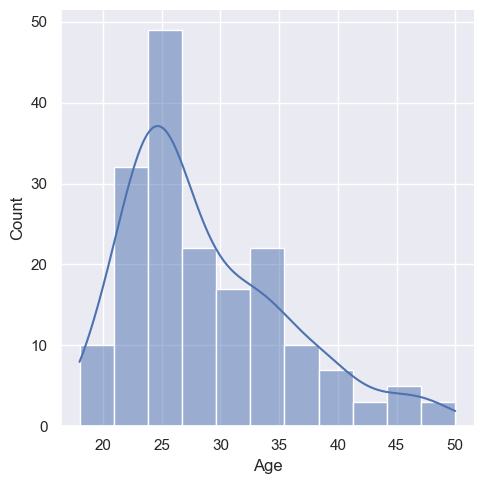

In [18]:
# plots a frequency polygon superimposed on a histogram
#sns.displot(Cardio['Age'],kde=False);
sns.displot(data=Cardio,x='Age',kde=True);

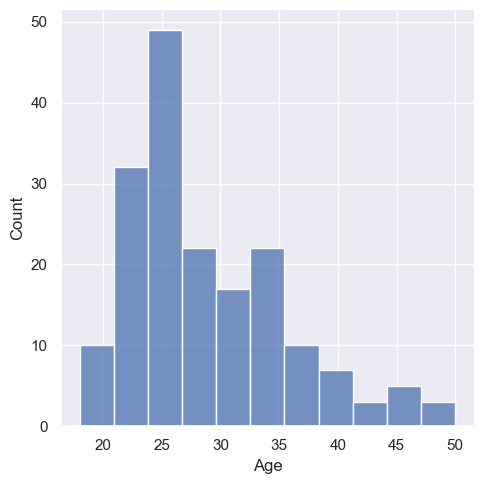

In [19]:
# alternative histogram
sns.displot(Cardio['Age'],kde=False);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


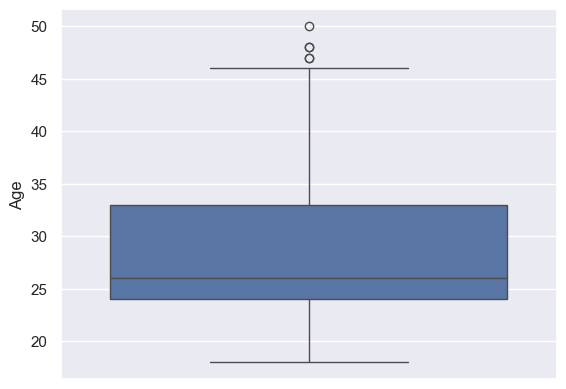

In [20]:
# display the box plot 
sns.boxplot(data=Cardio, y='Age'); 

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


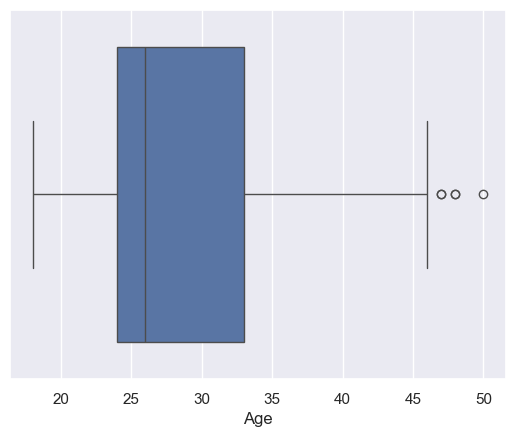

In [21]:
# alternative  
sns.boxplot(data=Cardio, x='Age'); 

Observations:
- Age - Mean=28.8 Mode=25, Median=26, Range=18-50, Mean>Median skewed right
- A few outliers on the upper range but appear that they could be accurate values. Mean is pulled higher due to these outliers. Will not adjust now but may revisit later.

In [22]:
Cardio.Education.describe()

count    180.000000
mean      15.572222
std        1.617055
min       12.000000
25%       14.000000
50%       16.000000
75%       16.000000
max       21.000000
Name: Education, dtype: float64

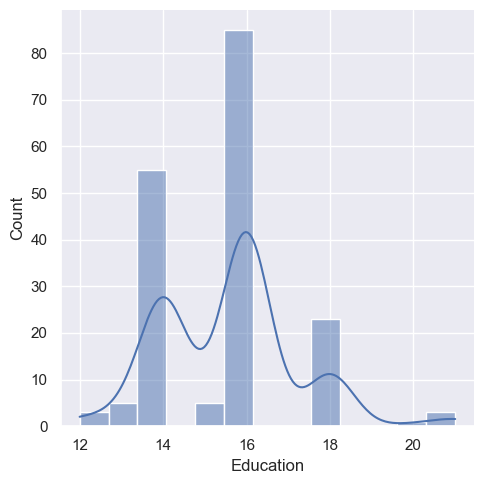

In [23]:
sns.displot(Cardio['Education'],kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


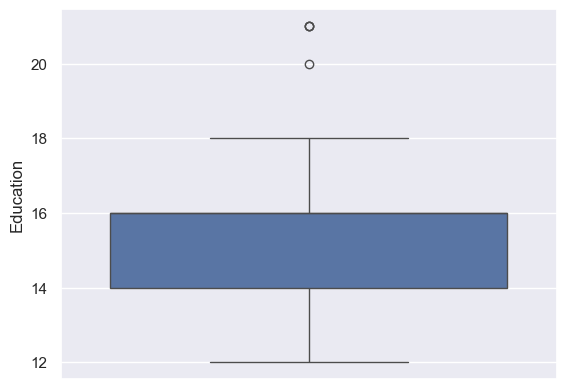

In [24]:
sns.boxplot(data=Cardio, y='Education'); 

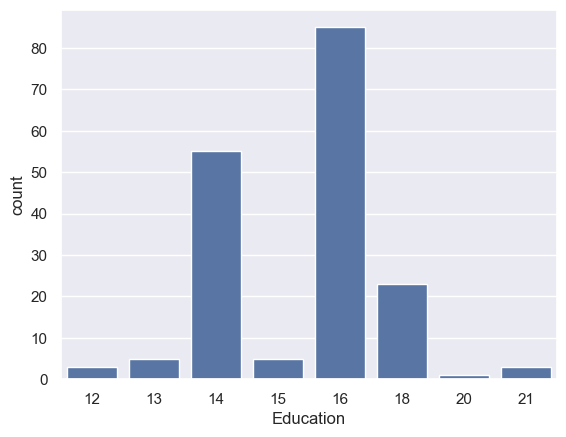

In [25]:
# even though Education is a numeric feature the values represent bins/categories so countplot can 
# provide meaningful info
sns.countplot(data=Cardio, x='Education'); 

Observations:
- Education - Mean=15.6 Mode=16, Median=16, Range=12-22 
- A few outliers on the upper range but appear that they could be accurate values. Mean is pulled higher due to these outliers. Will not adjust now but may revisit later.

Cardio.Usage.describe()

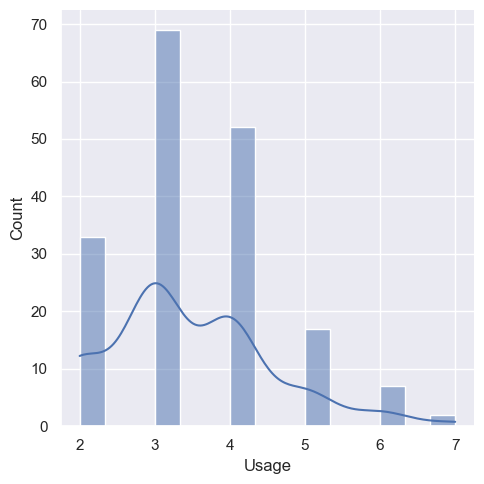

In [26]:
sns.displot(Cardio['Usage'],kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


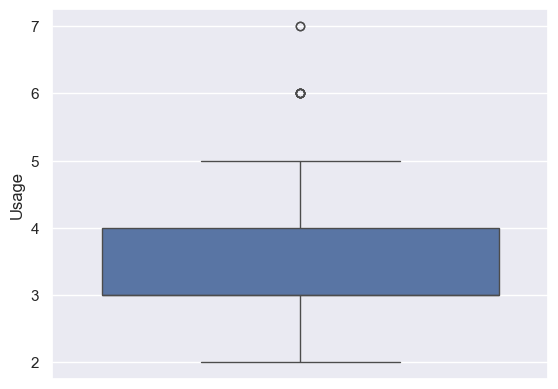

In [27]:
sns.boxplot(data=Cardio, y='Usage'); 

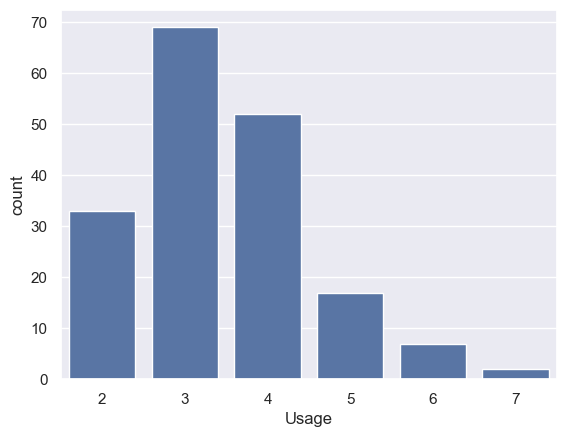

In [28]:
# even though Usage is a numeric feature the values represent bins/categories so countplot can 
# provide meaningful info
sns.countplot(data=Cardio, x='Usage'); 

Observations:
- Usage - Mean=3.4 Mode=3, Median=3, Range=2-7, Mean>Median skewed right
- A few outliers on the upper range but appear that they could be accurate values.  Mean is pulled higher due to these outliers.  Will not adjust now but may revisit later.
- 3 and 4 days a week is the most popular usage

In [29]:
Cardio.Fitness.describe()

count    180.000000
mean       3.311111
std        0.958869
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Fitness, dtype: float64

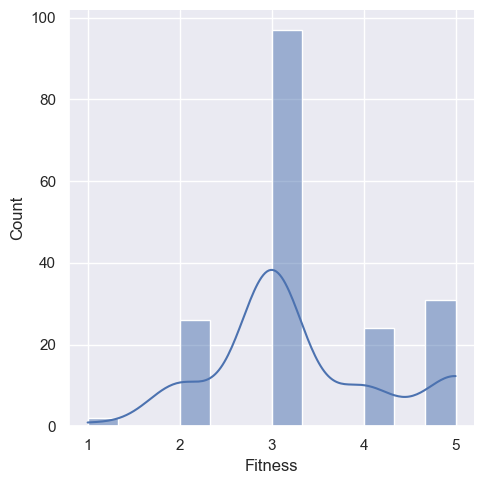

In [30]:
sns.displot(Cardio['Fitness'],kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


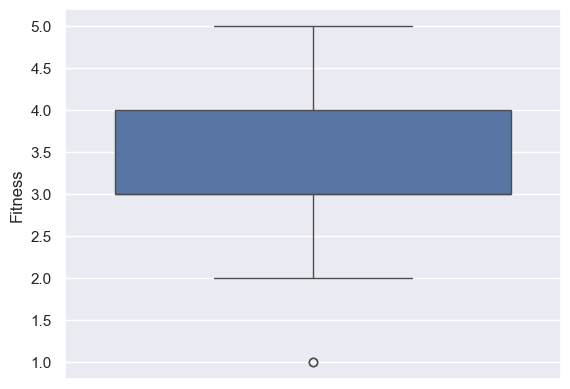

In [31]:
sns.boxplot(data=Cardio, y='Fitness'); 

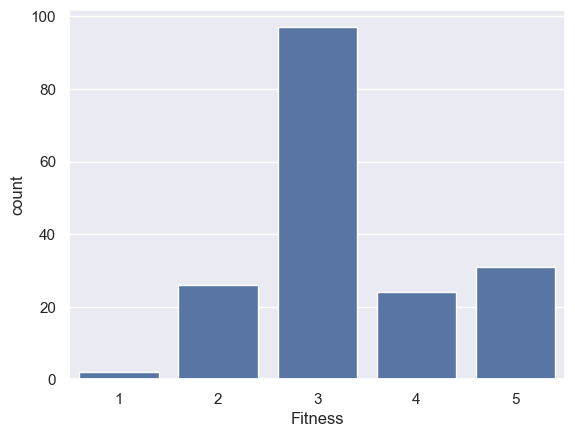

In [32]:
# even though Fitness is a numeric feature the values represent bins/categories so countplot can 
# provide meaningful info
sns.countplot(data=Cardio, x='Fitness'); 

Observations:
- Fitness - Mean=3.3 Mode=3, Median=3, Range=1-5
- No apparent outliers to consider
- Most customers consider their fitness level to be 3

In [33]:
Cardio.Income.describe()

count       180.000000
mean      53719.577778
std       16506.684226
min       29562.000000
25%       44058.750000
50%       50596.500000
75%       58668.000000
max      104581.000000
Name: Income, dtype: float64

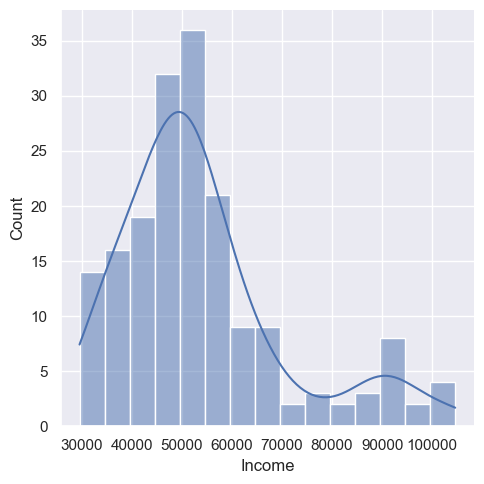

In [34]:
sns.displot(Cardio['Income'],kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


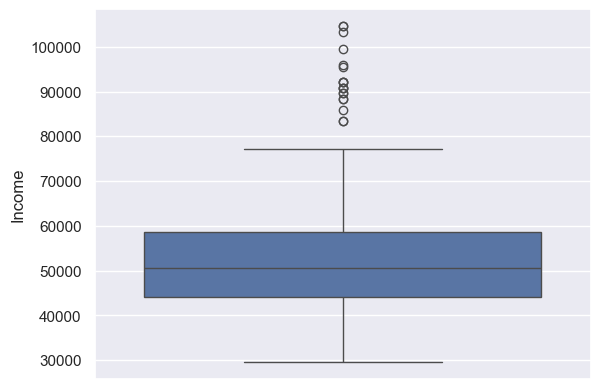

In [35]:
sns.boxplot(data=Cardio, y='Income'); 

Observations:
- Income - Mean=53719.6 Mode=45480, Median=50596.5, Range=29562-104581, Mean>Median skewed right
- Many outliers on the upper range. Mean is pulled higher due to these outliers. 

In [36]:
Cardio.Miles.describe()

count    180.000000
mean     103.194444
std       51.863605
min       21.000000
25%       66.000000
50%       94.000000
75%      114.750000
max      360.000000
Name: Miles, dtype: float64

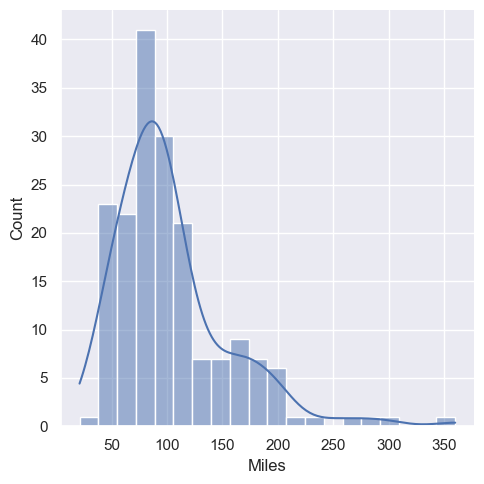

In [37]:
sns.displot(Cardio['Miles'],kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


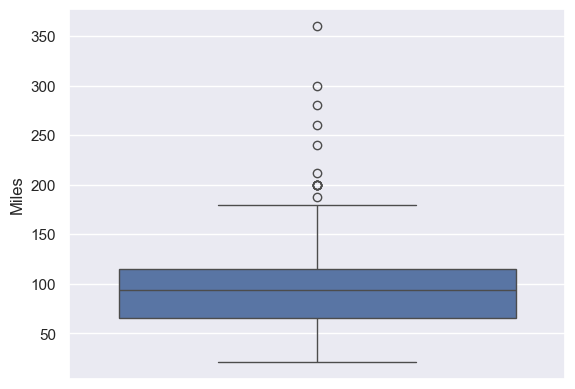

In [38]:
sns.boxplot(data=Cardio, y='Miles'); 

Observations:
- Miles - Mean=103.2 Mode=55, Median=94, Range=18-50, Mean>Median skewed right
- Many outliers on the upper range. Mean is pulled higher due to these outliers. 

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'Usage'}>,
        <Axes: title={'center': 'Fitness'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Miles'}>]], dtype=object)

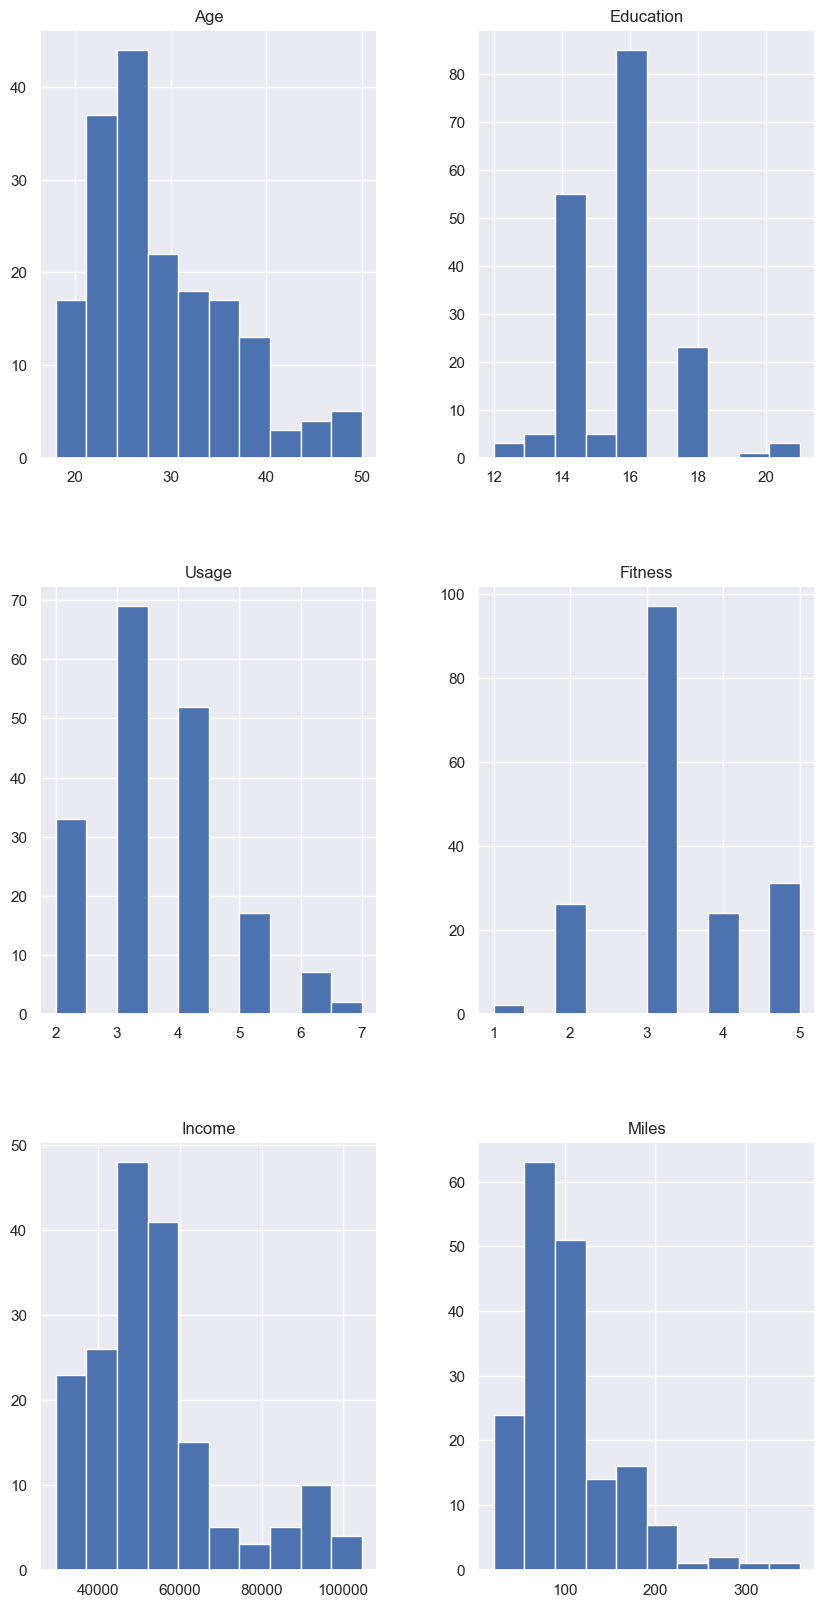

In [39]:
# alternative way to show histograms
Cardio.hist(figsize=(10,20))

#### Explore the categorial features in the dataset - Product, Gender, Marital Status

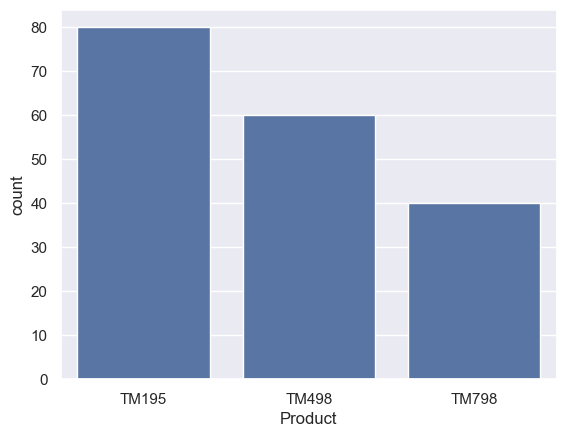

In [40]:
sns.countplot(data=Cardio, x='Product');

Observation:  Products - TM195 has sold the most, followed by TM498, followed by TM796

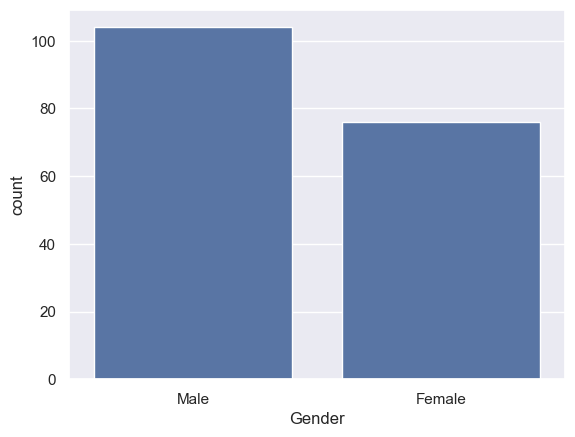

In [41]:
sns.countplot(data=Cardio, x='Gender');

Observation: Gender - More customers are male than female

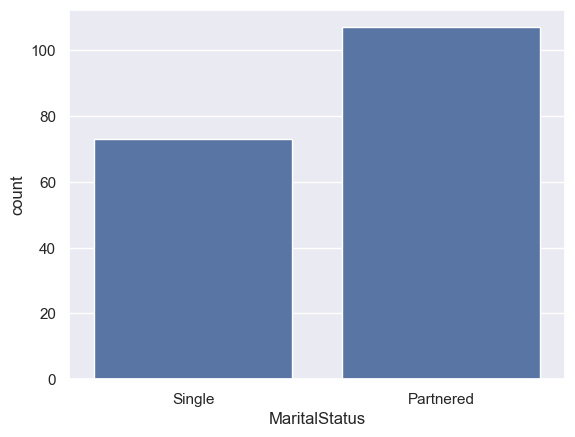

In [42]:
sns.countplot(data=Cardio, x='MaritalStatus');

Observation: Marital Status - More customers are partnered than single

### Bivariate Analysis

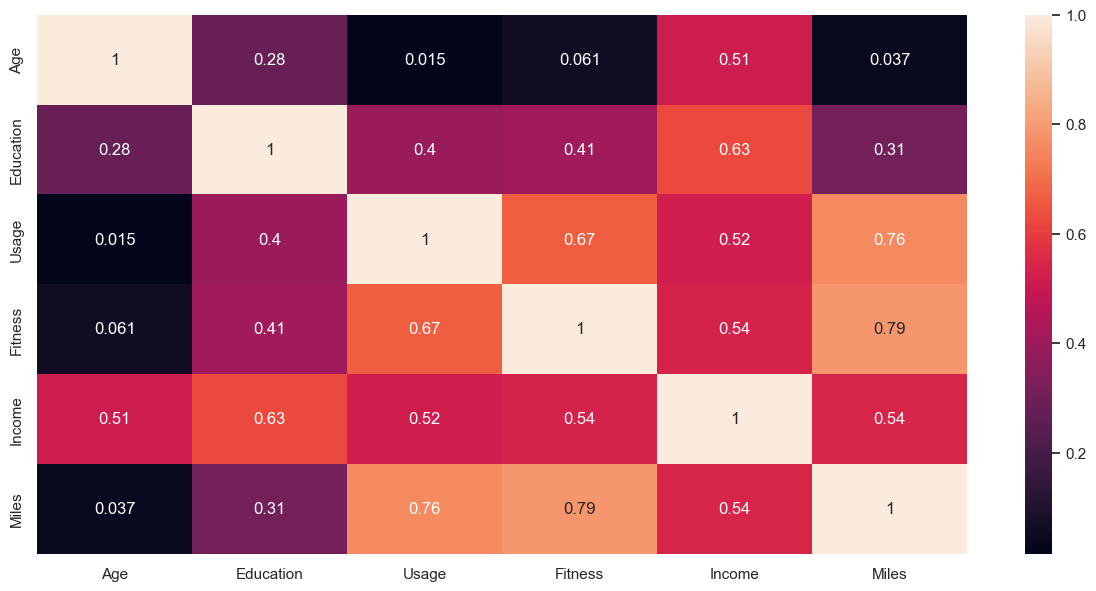

In [43]:
# display the correlations visually in a heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(Cardio.corr(numeric_only=True),annot=True);

Observations: 
- Highest correlation is between Usage/Miles and Fitness/Miles. 
- Income is moderately correlated to all other features. Meaning as income goes up so do the other variables or visa versa. This flows logically for age, education. It is interesting that it correlates similarly with Usage, Fitness, and Miles.
- Other than Income, Age and Education are not very correlated to any other features. They do not seem to have a positive or negative effect on Usage, Fitness, or Miles.
- Usage, Fitness, and Miles are positively correlated to each other. For example,if a cuustomer has a high Usage per week, they also likely have a high fitness level and high number of miles they plan to run.

#### Use pairplot to create scatterplots and histograms for the numeric columns

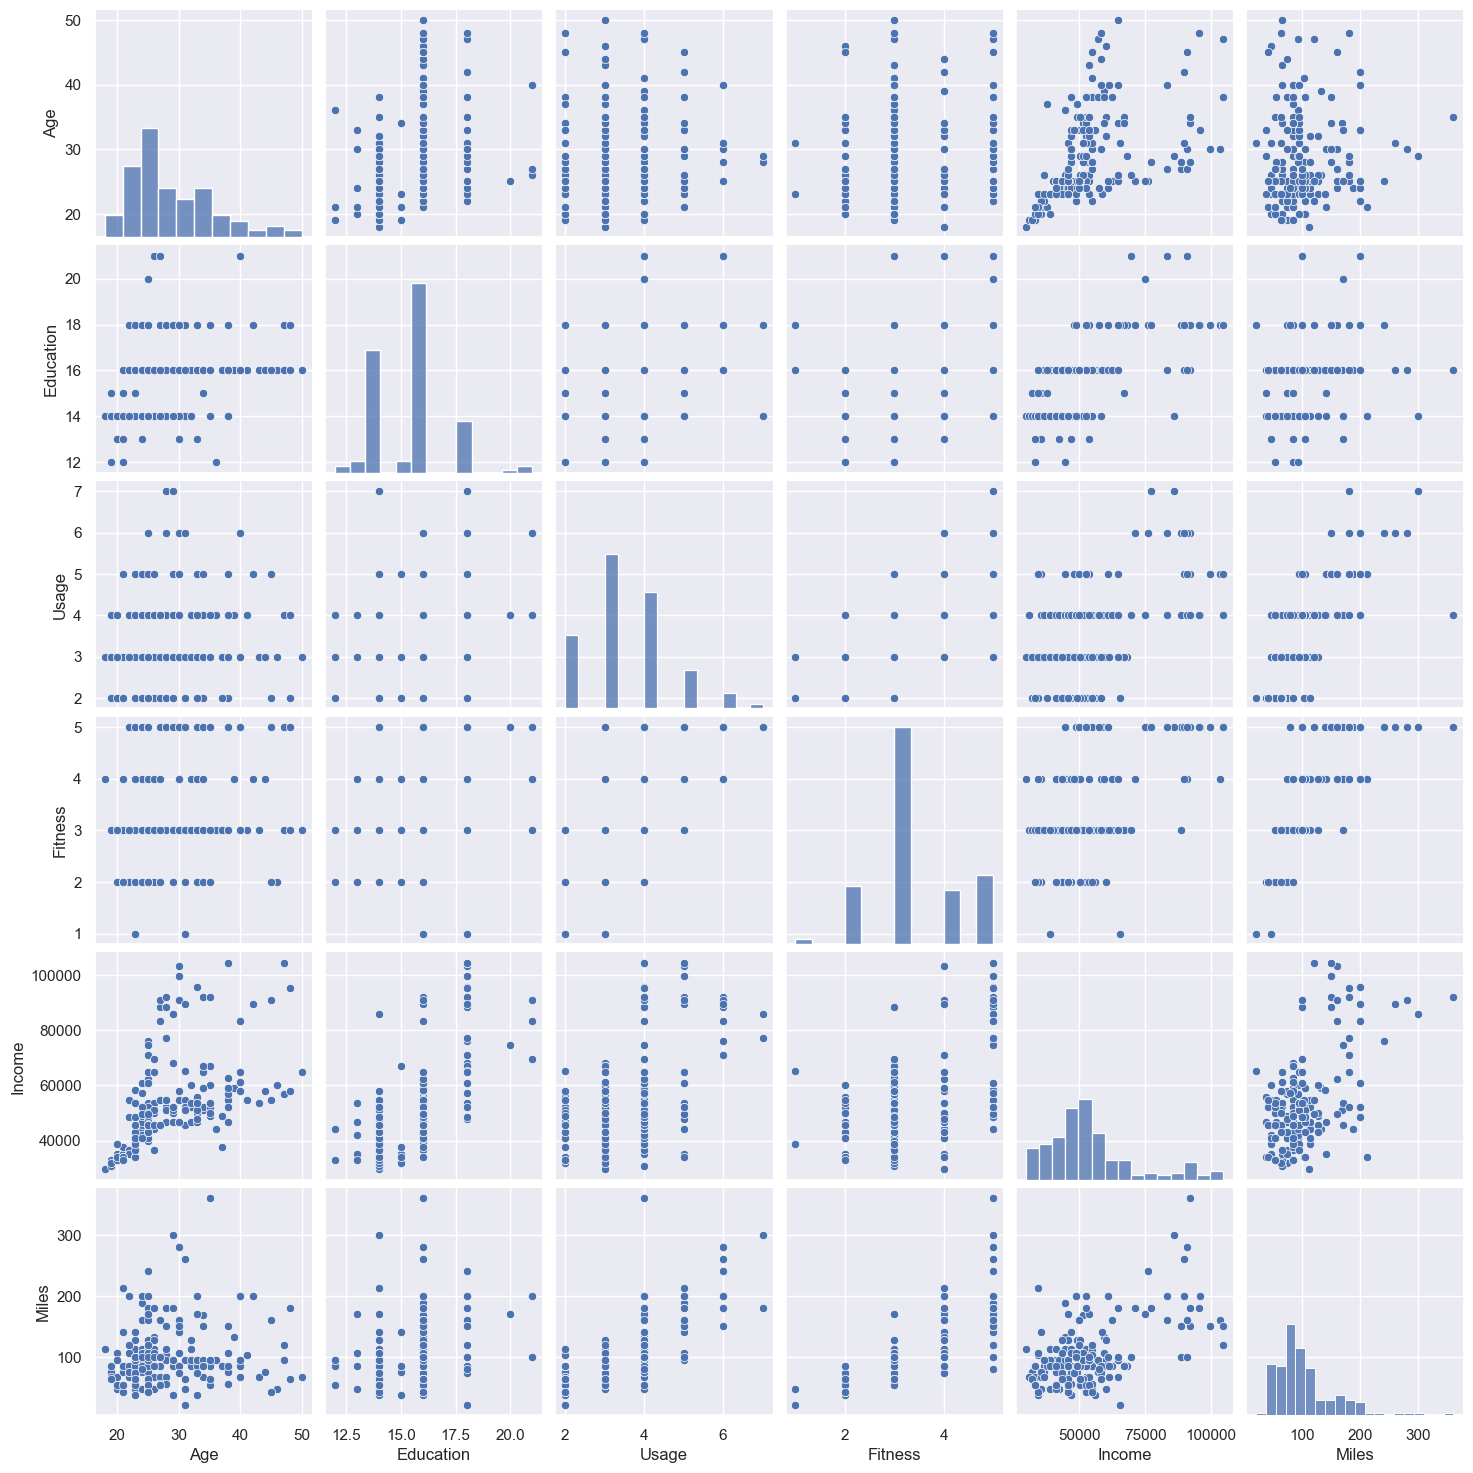

In [44]:
sns.pairplot(Cardio, diag_kind="hist"); 

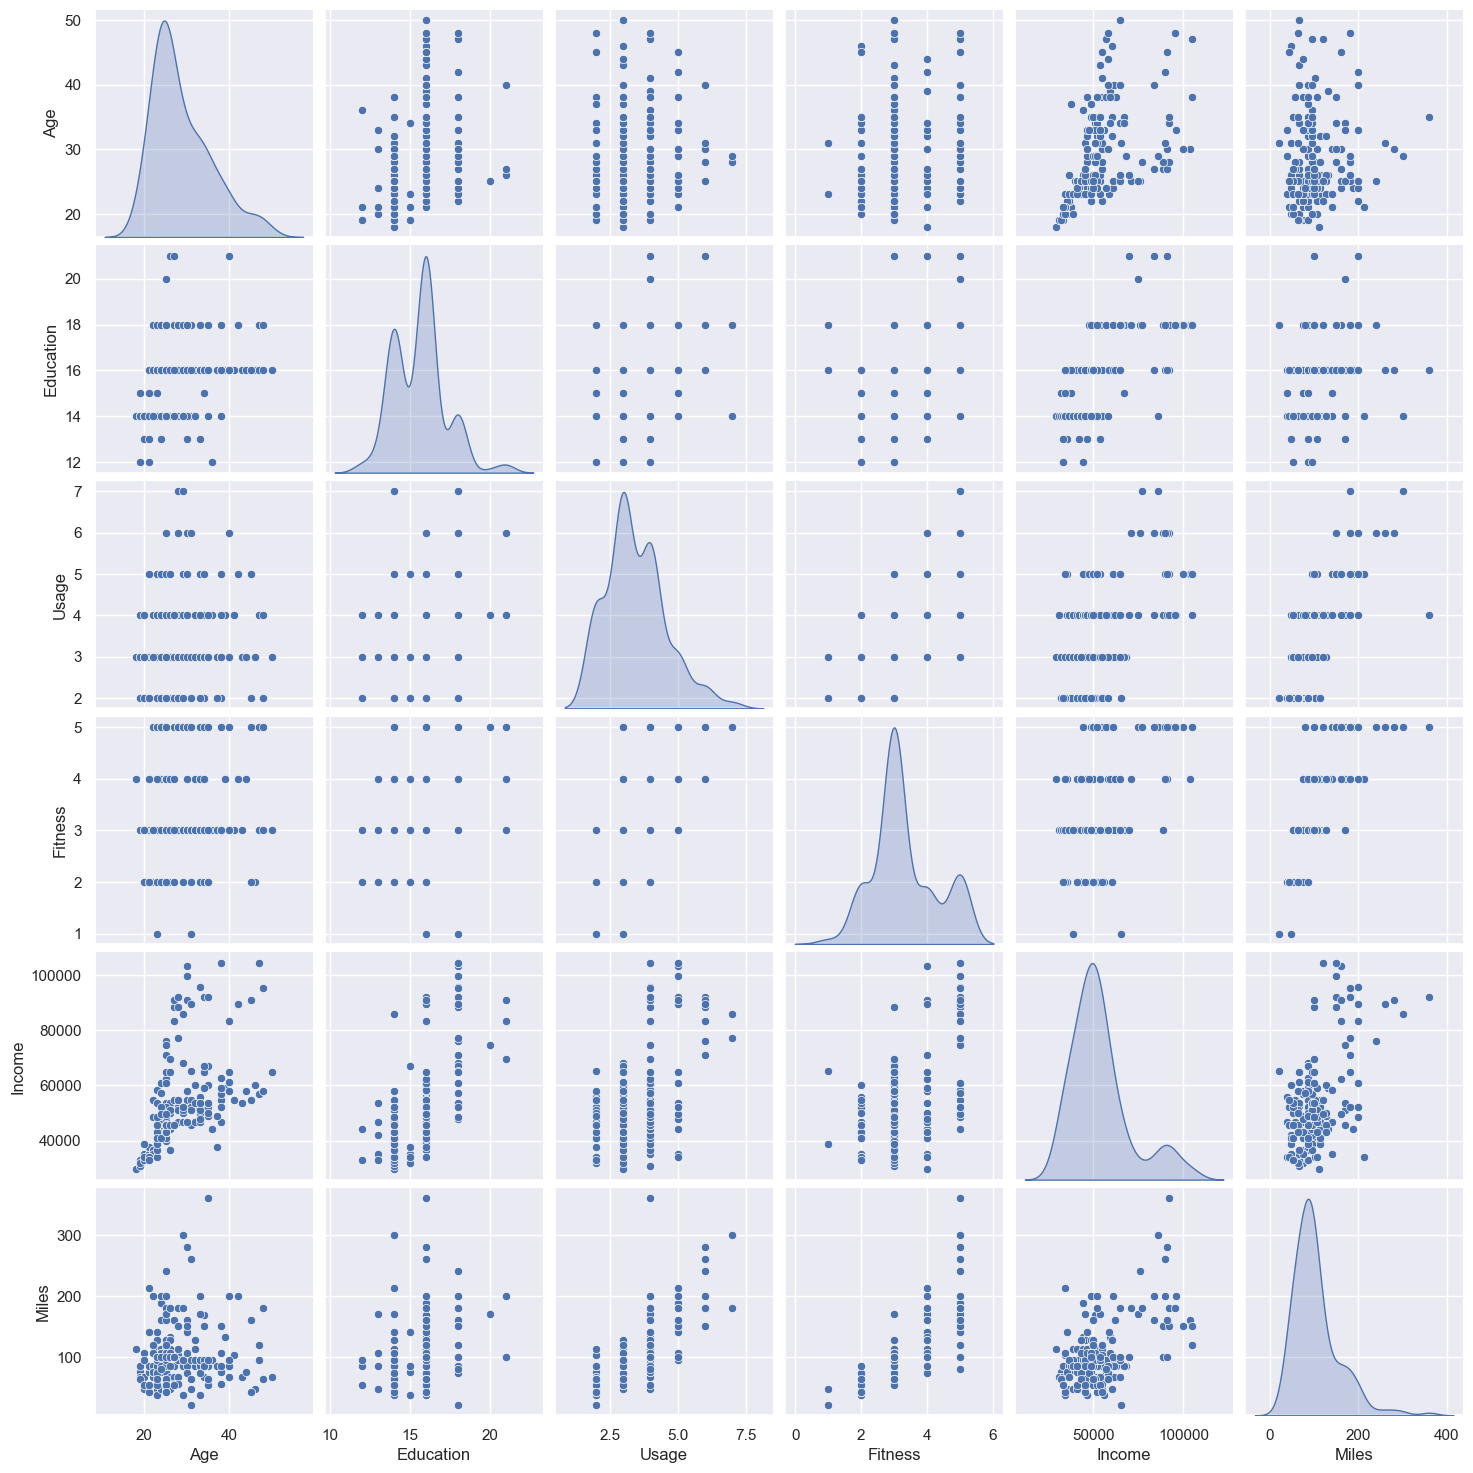

In [45]:
# alternative
sns.pairplot(Cardio, diag_kind="kde"); 

#### For each product, find the mean values of the numeric columns

In [46]:
selected = Cardio[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']]
selected.groupby(Cardio['Product']).mean()

,Age,Education,Usage,Fitness,Income,Miles
Product,,,,,,
TM195,28.55,15.037500,3.087500,2.9625,46418.025,82.787500
TM498,28.90,15.116667,3.066667,2.9000,48973.650,87.933333
TM798,29.10,17.325000,4.775000,4.6250,75441.575,166.900000


Observation: 
Customer profile per product: 
- TM195 is the youngest age demographic, the least education, has the lowest income and plans to run the least amount of miles.  It has middle usage per week and is in the middle for fitnes level. 
- TM498 is the middle age demographic, middle education, middle income and plans to run the middle amount of miles.  It has the lowest usage per week and in the lowest fitness level.  
- TM798 is the hightest in all six categories.  Other than Age, there is a signnificant difference in values between this product and the other two.
    

### Use countplots and crosstabs to compare the nonnumeric columns by product

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

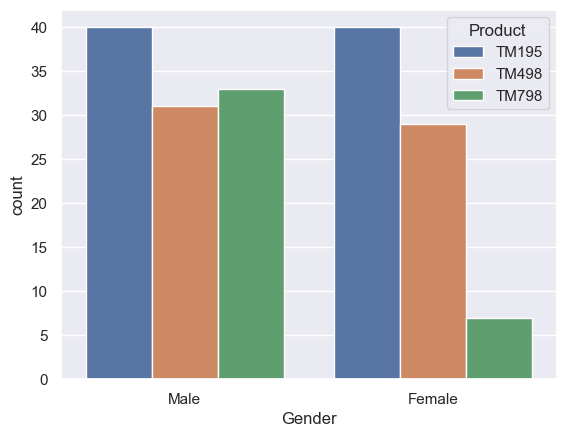

In [47]:
sns.countplot(data=Cardio,hue='Product', x='Gender');

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


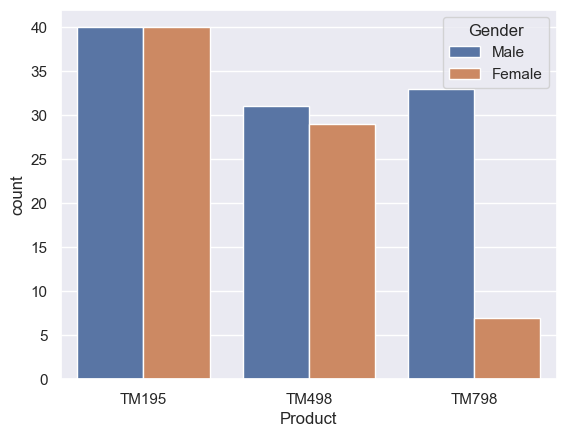

In [48]:
# another view of the countplot
sns.countplot(data=Cardio,hue='Gender', x='Product');

In [49]:
pd.crosstab(Cardio['Product'],Cardio['Gender'])

Gender,Female,Male
Product,,
TM195,40,40
TM498,29,31
TM798,7,33


Observation: Product TM195 and TM498 are purchased near equally by male and females.  TM798 is purchased significantly more by males than females.

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

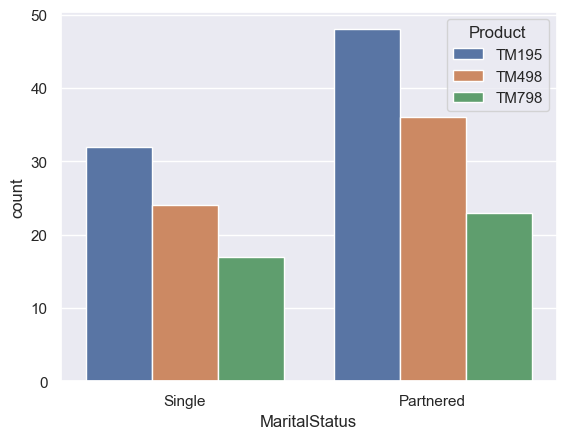

In [50]:
sns.countplot(data=Cardio,hue='Product', x='MaritalStatus');

In [51]:
pd.crosstab(Cardio['Product'],Cardio['MaritalStatus'])

MaritalStatus,Partnered,Single
Product,,
TM195,48,32
TM498,36,24
TM798,23,17


Observation: The pattern of purchasing of the various products is similar between Single and Partnered marital status.

#### Create box charts based on Product for each numeric column. Also find the mean, min and max values based on Product for the numeric columns

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


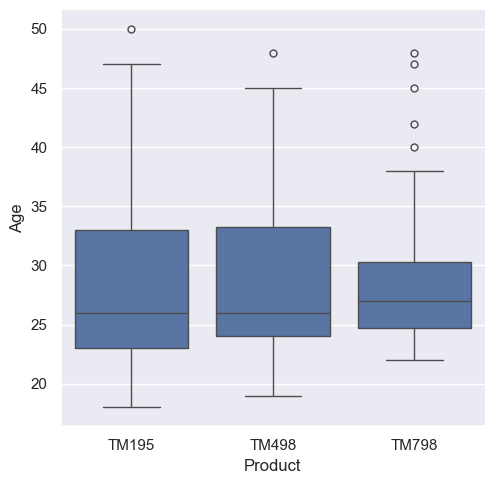

In [52]:
sns.catplot(x="Product", y = "Age", data=Cardio, kind="box");

In [53]:
print (Cardio.groupby(['Product']).Age.mean(), Cardio.groupby(['Product']).Age.min(), Cardio.groupby(['Product']).Age.max())

Product
TM195    28.55
TM498    28.90
TM798    29.10
Name: Age, dtype: float64 Product
TM195    18
TM498    19
TM798    22
Name: Age, dtype: int64 Product
TM195    50
TM498    48
TM798    48
Name: Age, dtype: int64


Observation: The Age range for TM798 is more narrow with a few (older) outliers. 

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


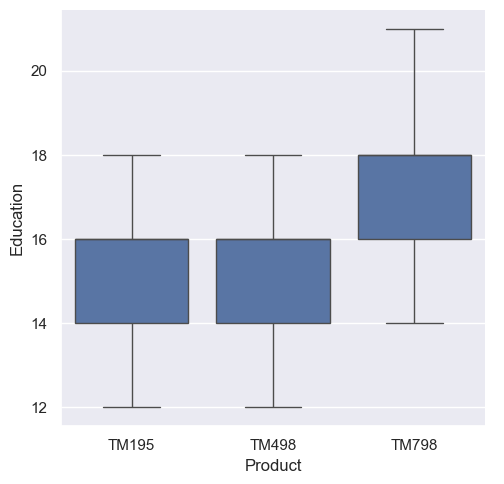

In [54]:
sns.catplot(x="Product", y = "Education", data=Cardio, kind="box");

In [55]:
print (Cardio.groupby(['Product']).Education.mean(), Cardio.groupby(['Product']).Education.min(), Cardio.groupby(['Product']).Education.max())

Product
TM195    15.037500
TM498    15.116667
TM798    17.325000
Name: Education, dtype: float64 Product
TM195    12
TM498    12
TM798    14
Name: Education, dtype: int64 Product
TM195    18
TM498    18
TM798    21
Name: Education, dtype: int64


Observation: Only 25% of TM195 and TM498 Sales are over an education level of 16 while only 25% of TM798 Sales are under an education level of 16.

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


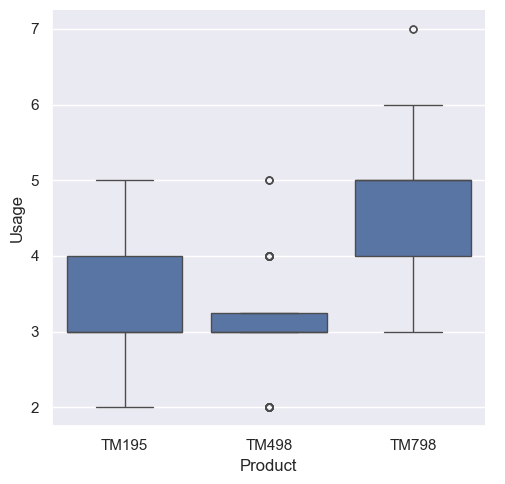

In [56]:
sns.catplot(x="Product", y = "Usage", data=Cardio, kind="box");

In [57]:
print (Cardio.groupby(['Product']).Usage.mean(), Cardio.groupby(['Product']).Usage.min(), Cardio.groupby(['Product']).Usage.max())

Product
TM195    3.087500
TM498    3.066667
TM798    4.775000
Name: Usage, dtype: float64 Product
TM195    2
TM498    2
TM798    3
Name: Usage, dtype: int64 Product
TM195    5
TM498    5
TM798    7
Name: Usage, dtype: int64


Observation: TM498 is primarily purchased by customers who plan to use the product 3 times a week (with only a few outliers). TM195 is primarily purchased by customers who plan to use the product 3-4 times a week. TM798 is primarily purchased by customers who plan to use the product 4-5 times a week.

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


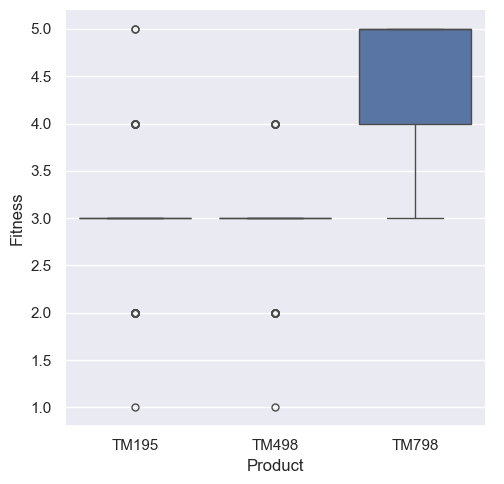

In [58]:
sns.catplot(x="Product", y = "Fitness", data=Cardio, kind="box");

In [59]:
print (Cardio.groupby(['Product']).Fitness.mean(), Cardio.groupby(['Product']).Fitness.min(), Cardio.groupby(['Product']).Fitness.max())

Product
TM195    2.9625
TM498    2.9000
TM798    4.6250
Name: Fitness, dtype: float64 Product
TM195    1
TM498    1
TM798    3
Name: Fitness, dtype: int64 Product
TM195    5
TM498    4
TM798    5
Name: Fitness, dtype: int64


Observation: TM195 and TM498 are primarily purchased by customers rate themselves at a fitness level of 3 (with a few outliers). TM798 is primarily purchased by customers who rate themselves at a fitness level of 4 or 5. 

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


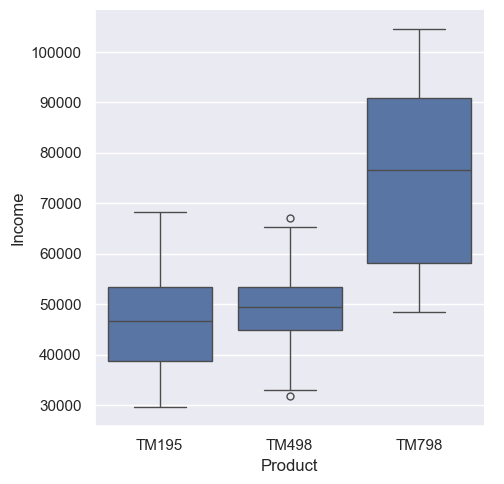

In [60]:
sns.catplot(x="Product", y="Income", data=Cardio, kind="box");

In [61]:
print (Cardio.groupby(['Product']).Income.mean(), Cardio.groupby(['Product']).Income.min(), Cardio.groupby(['Product']).Income.max())

Product
TM195    46418.025
TM498    48973.650
TM798    75441.575
Name: Income, dtype: float64 Product
TM195    29562
TM498    31836
TM798    48556
Name: Income, dtype: int64 Product
TM195     68220
TM498     67083
TM798    104581
Name: Income, dtype: int64


Observation: TM195 and TM498 are primarily purchased by customers who have an income of less than 55,000. TM798 is primarily purchased by customers who have an income of more than 60,000. 

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


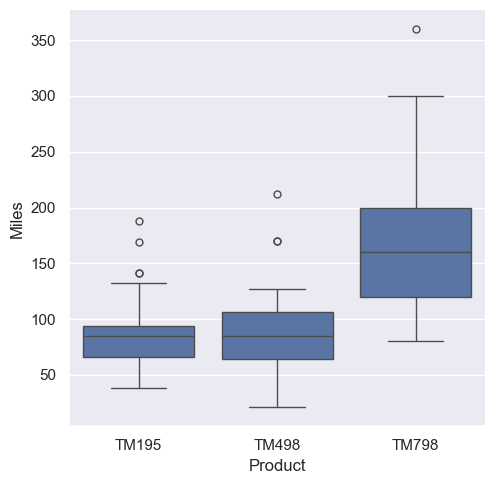

In [62]:
sns.catplot(x="Product", y = "Miles", data=Cardio, kind="box");

In [63]:
print (Cardio.groupby(['Product']).Miles.mean(), Cardio.groupby(['Product']).Miles.min(), Cardio.groupby(['Product']).Miles.max())

Product
TM195     82.787500
TM498     87.933333
TM798    166.900000
Name: Miles, dtype: float64 Product
TM195    38
TM498    21
TM798    80
Name: Miles, dtype: int64 Product
TM195    188
TM498    212
TM798    360
Name: Miles, dtype: int64


Observation: TM195 and TM498 are primarily purchased by customers who plan to run 100 miles or less.  There are a few oultliers for both products who plan to run more. TM798 is purchased primarily by customers who plan to run 125 miles or more. 

#### Statistical observations for each Product

In [64]:
Cardio[Cardio['Product']=='TM195'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,80.000000,80.000000,80.000000,80.00000,80.00000,80.000000
mean,28.550000,15.037500,3.087500,2.96250,46418.02500,82.787500
std,7.221452,1.216383,0.782624,0.66454,9075.78319,28.874102
min,18.000000,12.000000,2.000000,1.00000,29562.00000,38.000000
25%,23.000000,14.000000,3.000000,3.00000,38658.00000,66.000000
50%,26.000000,16.000000,3.000000,3.00000,46617.00000,85.000000
75%,33.000000,16.000000,4.000000,3.00000,53439.00000,94.000000
max,50.000000,18.000000,5.000000,5.00000,68220.00000,188.000000


Observation:
- 80 customers bought TM195 model
- Average age of customer who purchases TM195 is 28.5
- Average Education is 15
- Expected usage is 3 day a week
- Avg fitness level of 3
- Avg Income is 46,418
- Avg expected Miles is 82.78 miles per week

In [65]:
Cardio[Cardio['Product']=='TM498'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000
mean,28.900000,15.116667,3.066667,2.90000,48973.650000,87.933333
std,6.645248,1.222552,0.799717,0.62977,8653.989388,33.263135
min,19.000000,12.000000,2.000000,1.00000,31836.000000,21.000000
25%,24.000000,14.000000,3.000000,3.00000,44911.500000,64.000000
50%,26.000000,16.000000,3.000000,3.00000,49459.500000,85.000000
75%,33.250000,16.000000,3.250000,3.00000,53439.000000,106.000000
max,48.000000,18.000000,5.000000,4.00000,67083.000000,212.000000


###### Observation:
- 60 customers bought TM195 model
- Average age of customer who purchases TM195 is 28.9
- Average Education is 15
- Expected usage is 3 day a week
- Avg fitness level of 3
- Avg Income is 48,973
- Avg expected Miles is 87.3 miles per week

In [66]:
Cardio[Cardio['Product']=='TM798'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000
mean,29.100000,17.325000,4.775000,4.625000,75441.57500,166.900000
std,6.971738,1.639066,0.946993,0.667467,18505.83672,60.066544
min,22.000000,14.000000,3.000000,3.000000,48556.00000,80.000000
25%,24.750000,16.000000,4.000000,4.000000,58204.75000,120.000000
50%,27.000000,18.000000,5.000000,5.000000,76568.50000,160.000000
75%,30.250000,18.000000,5.000000,5.000000,90886.00000,200.000000
max,48.000000,21.000000,7.000000,5.000000,104581.00000,360.000000


Observation:
- 40 customers bought TM195 model
- Average age of customer who purchases TM195 is 29.1
- Average Education is 17
- Expected usage is 5 day a week
- Avg fitness level of 4.6
- Avg Income is 75,442
- Avg expected Miles is 167 miles per week

#### Use pointplot to see the relationship between Miles and Usage based on Fitness level

C:\Users\codyd\AppData\Local\Temp\ipykernel_17756\3865341185.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='Usage', y='Miles', data=Cardio, hue='Fitness', ci=None);
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base

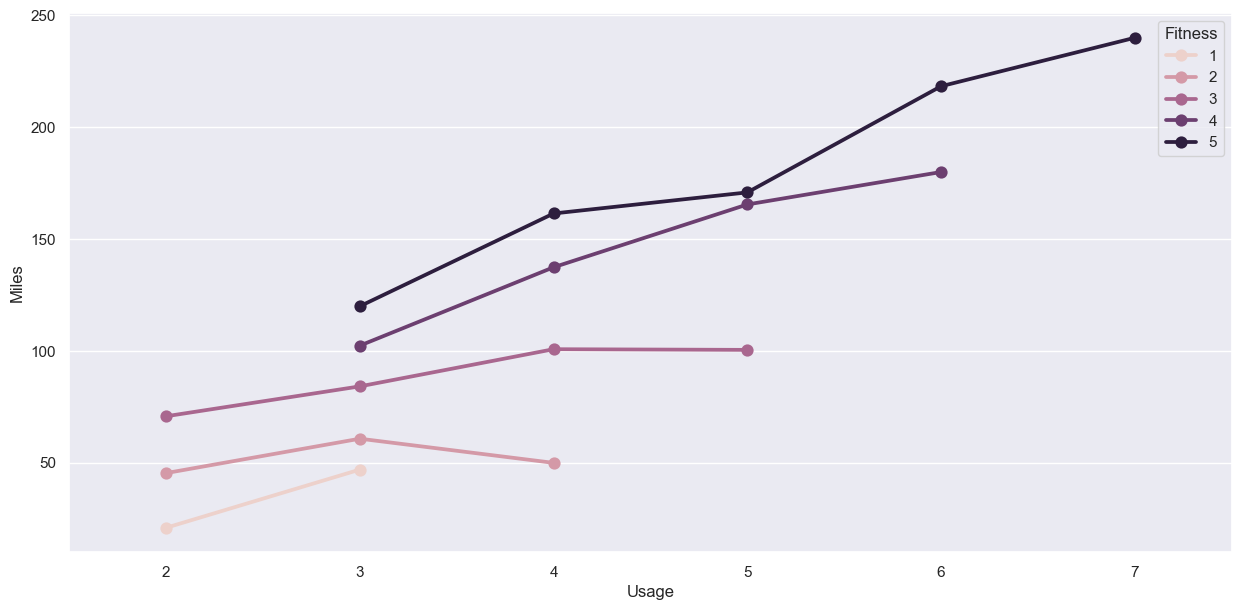

In [67]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Usage', y='Miles', data=Cardio, hue='Fitness', ci=None);

## Conclusions and Recommendations

Analyzing the provided Cardio Good Fitness dataset provided many insights about the customers that purchase the three treadmills - TM195, TM498, and TM798. With this analysis, we can identify target customers for each of the three products.  Creating customer profiles for the products will help the organization engage with appropriate prospective customers.  Focusing marketing efforts based on the demographics in the dataset will allow the organization to target the right people. It will also allow them to make knowledgable pricing and product adjustments.

Two of the treadmills, TM195 and TM498, are purchased by similar customers.  The characteristics of these customers include:
- Age: IQR (Interquartile Range) of the ages of customers purchasing these two products is 23-33. 
- Gender: Product TM195 and TM498 are purchased near equally by male and females.
- Education: IQR of the education level of customers purchasing these two products is 14-16 with 12 being the min and 18 being the max. 
- MaritalStatus: More customers of these two products are partnered than single.
- Usage: TM498 is primarily purchased by customers who plan to use the product 3 times a week (with only a few outliers). TM195 is primarily purchased by customers who plan to use the product 3-4 times a week.
- Fitness: TM195 and TM498 are primarily purchased by customers who rate themselves at a fitness level of 3 (with a few outliers). 
- Income: TM195 and TM498 are primarily purchased by customers who have an income of less than 55,000 with a mean income of 47,500.
- Miles: TM195 and TM498 are primarily purchased by customers who plan to run 100 miles or less.

The other treadmill, TM798, is purchased by a different type of customer.  The characteristics of this customer include: 
- Age: IQR of the ages of customers purchasing TM798 is 25-30. This is a much more narrow age group than the other two products. 
- Gender: TM798 is purchased significantly more by males than females.
- Education: IQR of the education level of customers purchasing this product is 16-18 with 14 being the min and 21 being the max.
-  MaritalStatus: TM798 was purchased by 18 single customers vs. 22 partnered customers.  This is significantly more balanced than the other two products.
- Usage: TM798 is primarily purchased by customers who plan to use the product 4-5 times a week.
- Fitness: TM798 is primarily purchased by customers who rate themselves at a fitness level of 4 or 5.
- Income: TM798 is primarily purchased by customers who have an income of more than 60,000 with an average income of 77,500.  This is significantly higher than the other two products.
- Miles: TM798 is purchased primarily by customers who plan to run 125 miles or more. 

The characteristics of the typical customer for TM195 and TM498 versus the typical customer for TM798 are quite different. Therefore, it is important to target the marketing of these products differently. First, let's take a look at the TM798 customer. The prospective customer is a fitness enthusiast - has a high fitness level, plans to use the treadmill often, and plans to run significant miles on it. He is also male aged 25-30.  Finally, he/she is highly educationed and has a high income.  Concentrating marketing efforts on markets that match these characteristics, such as men's fitness magazines, could allow the organization to dominate a niche in the market. Also, due to the affluence of the typical customer, price likely does not influence the purchasing decisions of the customer.  This allows for changes in product improvements and price. 

On the other hand, the characteristics of the typical customer for TM195 and TM498 are much more general.  The typical customer is more of a moderate fitness person - they have a lower fitness level, plan to use less it, and run less miles on it.  They are just as likely to be either male or female and are aged 23 to 33.  They are less educated and earn less. These character should lead the organization to market these two products to broader customer segments.  They could be new to the fitness market or plan to use the treadmill to cross train for other fitness disciplines. Price likely has a significant influence on their purchasing decisions.  Therefore, this will need to be considered while making pricing and product changes. 

## Feature engineering

In [68]:
data = Cardio.copy()

### Feature Scaling

#### Standardization

In [70]:
Cardio.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(Cardio[['Age']])
Cardio[['Age']] = scaler.transform(Cardio[['Age']])

In [73]:
Cardio['Age']

0     -1.558146
1     -1.413725
2     -1.413725
3     -1.413725
4     -1.269303
         ...   
175    1.619124
176    1.907967
177    2.341231
178    2.630073
179    2.774495
Name: Age, Length: 180, dtype: float64

In [74]:
Cardio.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,-1.558146,Male,14,Single,3,4,29562,112
1,TM195,-1.413725,Male,15,Single,2,3,31836,75
2,TM195,-1.413725,Female,14,Partnered,4,3,30699,66
3,TM195,-1.413725,Male,12,Single,3,3,32973,85
4,TM195,-1.269303,Male,13,Partnered,4,2,35247,47


In [75]:
Cardio.Age.describe()

count    1.800000e+02
mean     1.282924e-16
std      1.002789e+00
min     -1.558146e+00
25%     -6.916178e-01
50%     -4.027751e-01
75%      6.081744e-01
max      3.063337e+00
Name: Age, dtype: float64

#### Min/Max Scaling

In [76]:
Cardio = data.copy()

In [77]:
Cardio.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [78]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(Cardio[['Age']])
Cardio[['Age']] = scaler.transform(Cardio[['Age']])

In [79]:
Cardio.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,0.00000,Male,14,Single,3,4,29562,112
1,TM195,0.03125,Male,15,Single,2,3,31836,75
2,TM195,0.03125,Female,14,Partnered,4,3,30699,66
3,TM195,0.03125,Male,12,Single,3,3,32973,85
4,TM195,0.06250,Male,13,Partnered,4,2,35247,47


In [80]:
Cardio.Age.describe()

count    180.000000
mean       0.337153
std        0.216984
min        0.000000
25%        0.187500
50%        0.250000
75%        0.468750
max        1.000000
Name: Age, dtype: float64

### Encoding Categorical Features

#### One Hot Encoding

In [81]:
Cardio.MaritalStatus.unique()

array(['Single', 'Partnered'], dtype=object)

In [82]:
Cardio.head(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,0.00000,Male,14,Single,3,4,29562,112
1,TM195,0.03125,Male,15,Single,2,3,31836,75
2,TM195,0.03125,Female,14,Partnered,4,3,30699,66
3,TM195,0.03125,Male,12,Single,3,3,32973,85
4,TM195,0.06250,Male,13,Partnered,4,2,35247,47
5,TM195,0.06250,Female,14,Partnered,3,3,32973,66
6,TM195,0.09375,Female,14,Partnered,3,3,35247,75
7,TM195,0.09375,Male,13,Single,3,3,32973,85
8,TM195,0.09375,Male,15,Single,5,4,35247,141
9,TM195,0.09375,Female,15,Partnered,2,3,37521,85


In [84]:
Cardio = pd.get_dummies(Cardio, columns=['MaritalStatus'], drop_first=True)

In [85]:
Cardio.head(10)

,Product,Age,Gender,Education,Usage,Fitness,Income,Miles,MaritalStatus_Single
0,TM195,0.00000,Male,14,3,4,29562,112,True
1,TM195,0.03125,Male,15,2,3,31836,75,True
2,TM195,0.03125,Female,14,4,3,30699,66,False
3,TM195,0.03125,Male,12,3,3,32973,85,True
4,TM195,0.06250,Male,13,4,2,35247,47,False
5,TM195,0.06250,Female,14,3,3,32973,66,False
6,TM195,0.09375,Female,14,3,3,35247,75,False
7,TM195,0.09375,Male,13,3,3,32973,85,True
8,TM195,0.09375,Male,15,5,4,35247,141,True
9,TM195,0.09375,Female,15,2,3,37521,85,False


#### Label Encoding

In [86]:
Cardio = data.copy()

In [87]:
Cardio.MaritalStatus.unique()

array(['Single', 'Partnered'], dtype=object)

In [88]:
Cardio.head(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47
5,TM195,20,Female,14,Partnered,3,3,32973,66
6,TM195,21,Female,14,Partnered,3,3,35247,75
7,TM195,21,Male,13,Single,3,3,32973,85
8,TM195,21,Male,15,Single,5,4,35247,141
9,TM195,21,Female,15,Partnered,2,3,37521,85


In [90]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
Cardio['MaritalStatus'] = label_encoder.fit_transform(Cardio['MaritalStatus'])

In [91]:
Cardio.head(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,1,3,4,29562,112
1,TM195,19,Male,15,1,2,3,31836,75
2,TM195,19,Female,14,0,4,3,30699,66
3,TM195,19,Male,12,1,3,3,32973,85
4,TM195,20,Male,13,0,4,2,35247,47
5,TM195,20,Female,14,0,3,3,32973,66
6,TM195,21,Female,14,0,3,3,35247,75
7,TM195,21,Male,13,1,3,3,32973,85
8,TM195,21,Male,15,1,5,4,35247,141
9,TM195,21,Female,15,0,2,3,37521,85


#### Binning

In [92]:
Cardio.Income.describe()

count       180.000000
mean      53719.577778
std       16506.684226
min       29562.000000
25%       44058.750000
50%       50596.500000
75%       58668.000000
max      104581.000000
Name: Income, dtype: float64

In [94]:
Cardio['Income_group'] = pd.cut(Cardio['Income'], bins=[29561.0, 44058.75, 50596.5, 58668.0, 104582.0],
                                labels=['Low', 'Medium Low', 'Medium High', 'High'])

In [95]:
Cardio.head(20)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Income_group
0,TM195,18,Male,14,1,3,4,29562,112,Low
1,TM195,19,Male,15,1,2,3,31836,75,Low
2,TM195,19,Female,14,0,4,3,30699,66,Low
3,TM195,19,Male,12,1,3,3,32973,85,Low
4,TM195,20,Male,13,0,4,2,35247,47,Low
5,TM195,20,Female,14,0,3,3,32973,66,Low
6,TM195,21,Female,14,0,3,3,35247,75,Low
7,TM195,21,Male,13,1,3,3,32973,85,Low
8,TM195,21,Male,15,1,5,4,35247,141,Low
9,TM195,21,Female,15,0,2,3,37521,85,Low


In [96]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the feature - number of rows
    count = data[feature].nunique() # unique values of the feature
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

C:\Users\codyd\AppData\Local\Temp\ipykernel_17756\3006161057.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Pyth

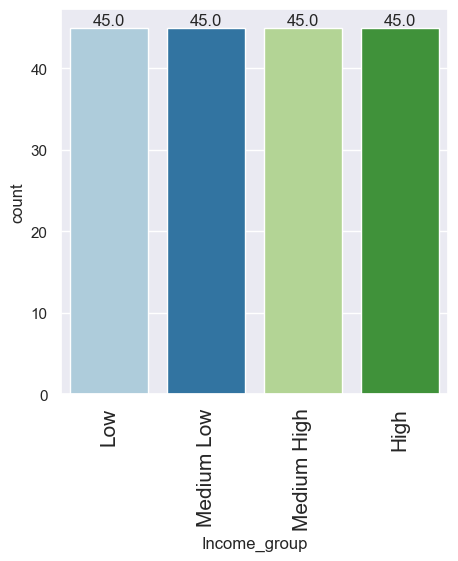

In [98]:
labeled_barplot(Cardio, 'Income_group');

In [103]:
df2 = Cardio.groupby(by=['Gender', 'MaritalStatus'], as_index=False).count()

In [104]:
df2

,Gender,MaritalStatus,Product,Age,Education,Usage,Fitness,Income,Miles,Income_group
0,Female,0,46,46,46,46,46,46,46,46
1,Female,1,30,30,30,30,30,30,30,30
2,Male,0,61,61,61,61,61,61,61,61
3,Male,1,43,43,43,43,43,43,43,43
